# Q1A — Frequency Forensics: "The Ghost Signal"

**Frequency-Domain Image Recovery System**

A reconnaissance image has been corrupted by a repetitive (periodic) interference
pattern. In the spatial domain the image looks destroyed, but periodic interference
leaves sharp, localized "fingerprints" in the frequency domain. This notebook:

1. Loads the corrupted image `ghost_signal_input.png`.
2. Derives and applies the 2‑D Discrete Fourier Transform (DFT).
3. Visualizes the magnitude spectrum (linear & dB, unshifted & shifted).
4. Automatically locates the interference peaks in the spectrum.
5. Designs and applies a notch (band-reject) filter to remove only the
   interference, while preserving the underlying image content.
6. Reconstructs the image with the inverse DFT and reveals the hidden message.
7. Studies how filter parameters affect reconstruction quality.
8. Discusses practical applications of frequency-domain restoration.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.ndimage import label

plt.rcParams['figure.dpi'] = 110


## 1. Load the corrupted image

$I(x,y)$ is treated as a finite 2‑D discrete signal: a grayscale image of size
$M \times N$, where $x \in \{0,\dots,M-1\}$ indexes rows and $y \in \{0,\dots,N-1\}$
indexes columns, and the intensity values are real numbers (here, 8-bit, $0$–$255$).

Image size: 264 rows x 517 columns


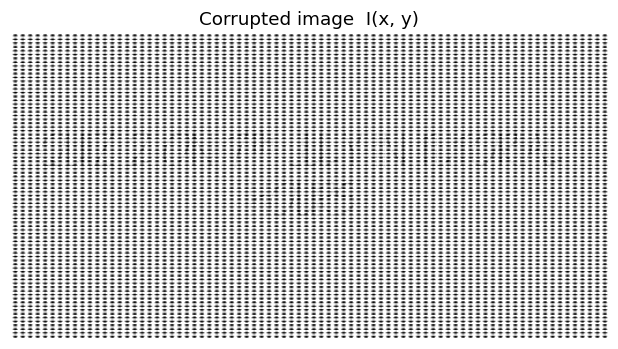

In [2]:
img_path = "ghost_signal_input.png"   # place the provided image in the same folder as this notebook

img = Image.open(img_path).convert("L")     # ensure single-channel grayscale
I = np.array(img).astype(np.float64)
M, N = I.shape
print(f"Image size: {M} rows x {N} columns")

plt.figure(figsize=(7,3.6))
plt.imshow(I, cmap='gray')
plt.title("Corrupted image  I(x, y)")
plt.axis('off')
plt.show()


## 2. The 2-D Discrete Fourier Transform (DFT) and its inverse

For a finite discrete image $I(x,y)$ of size $M \times N$ ($x = 0,\dots,M-1$,
$y = 0,\dots,N-1$), the **2-D DFT** is

$$
F(u,v) \;=\; \sum_{x=0}^{M-1}\sum_{y=0}^{N-1} I(x,y)\, e^{-j2\pi\left(\frac{ux}{M}+\frac{vy}{N}\right)},
\qquad u=0,\dots,M-1,\; v=0,\dots,N-1
$$

and the corresponding **inverse 2-D DFT (IDFT)** that reconstructs the image
from its spectrum is

$$
I(x,y) \;=\; \frac{1}{MN}\sum_{u=0}^{M-1}\sum_{v=0}^{N-1} F(u,v)\, e^{\,j2\pi\left(\frac{ux}{M}+\frac{vy}{N}\right)} .
$$

Here $u$ and $v$ are the spatial-frequency indices along the row and column
directions, respectively. Because the 2-D DFT is separable, it can be computed
as a 1-D DFT along the rows followed by a 1-D DFT along the columns (or vice
versa); in practice we never evaluate the double sum directly — instead we use
the **Fast Fourier Transform (FFT)**, which computes the identical result in
$O(MN\log(MN))$ time instead of $O(M^2N^2)$. `numpy.fft.fft2` implements
exactly the DFT formula above, and `numpy.fft.ifft2` implements the IDFT
formula above.

In [3]:
# 2-D DFT via FFT (mathematically identical to the double-sum definition above,
# just computed efficiently)
F = np.fft.fft2(I)
print("F.shape:", F.shape, " dtype:", F.dtype)   # complex-valued spectrum, same size as I


F.shape: (264, 517)  dtype: complex128


## 3. Magnitude spectrum — linear and dB scale (unshifted)

The magnitude spectrum is $|F(u,v)|$. Because natural-image spectra have an
*enormous* dynamic range (the DC term is typically $10^3$–$10^5$ times larger
than high-frequency content), a **linear-scale** plot of $|F(u,v)|$ shows
almost nothing but a single bright dot — everything else is crushed to black.
We therefore also plot the **log-magnitude (dB) spectrum**

$$
S_{\text{dB}}(u,v) = 20\log_{10}\big(|F(u,v)| + 1\big)
$$

(the "+1" only avoids $\log(0)$ for any exactly-zero bins). The dB scale
compresses the dynamic range and reveals weak but structured components that
are invisible on a linear scale.

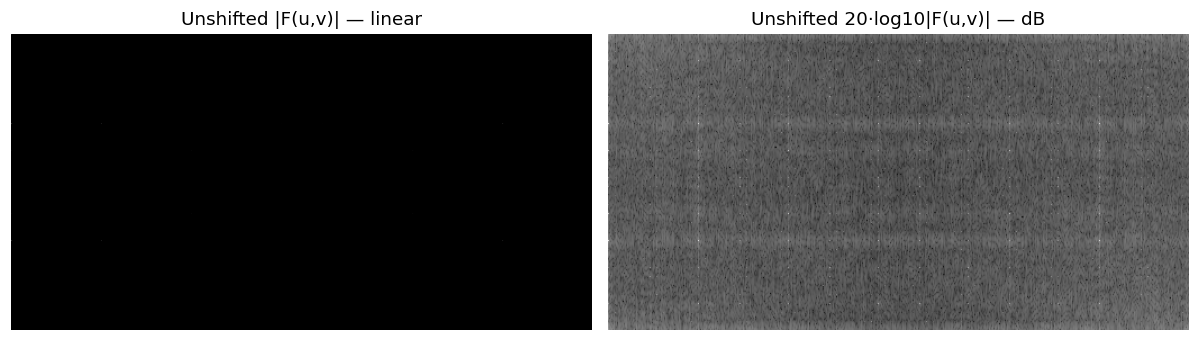

DC magnitude            : 2.654e+07
Median magnitude (other): 1.318e+03
Ratio DC / median       : 20,136x


In [4]:
mag_lin = np.abs(F)
mag_db  = 20*np.log10(mag_lin + 1)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].imshow(mag_lin, cmap='gray'); ax[0].set_title("Unshifted |F(u,v)| — linear"); ax[0].axis('off')
ax[1].imshow(mag_db,  cmap='gray'); ax[1].set_title("Unshifted 20·log10|F(u,v)| — dB"); ax[1].axis('off')
plt.tight_layout(); plt.show()

print(f"DC magnitude            : {mag_lin[0,0]:.3e}")
print(f"Median magnitude (other): {np.median(mag_lin):.3e}")
print(f"Ratio DC / median       : {mag_lin[0,0]/np.median(mag_lin):,.0f}x")


**Observation.** On the linear plot the DC component at $(u,v)=(0,0)$ dominates
everything else by several orders of magnitude (see the ratio printed above),
so the rest of the spectrum appears essentially black. The dB plot compresses
this enormous range logarithmically and reveals the fainter structure of the
spectrum — including the interference.

## 4. Centering the spectrum (`fftshift`)

`np.fft.fft2` returns $F(u,v)$ in the **natural FFT order**: the DC term
$F(0,0)$ is at the *top-left corner*, with frequency indices increasing outward
and wrapping around (since the DFT is periodic with period $M$ in $u$ and $N$
in $v$). Low frequencies are therefore split across all four corners of the
array, which is hard to interpret visually.

To get the conventional, human-readable layout — DC and the lowest frequencies
at the **center**, with frequency increasing radially outward — we apply a
**circular shift** of the spectrum by $M/2$ rows and $N/2$ columns. This is
exactly what `numpy.fft.fftshift` does:

$$
F_{\text{shifted}}(u,v) = F\big((u - M/2)\bmod M,\;(v - N/2)\bmod N\big)
$$

This works because shifting an image by half its period in the spatial domain
is equivalent (by the DFT's periodicity/shift property) to swapping quadrants
in the frequency domain — no information is lost, only the *display* layout
changes.

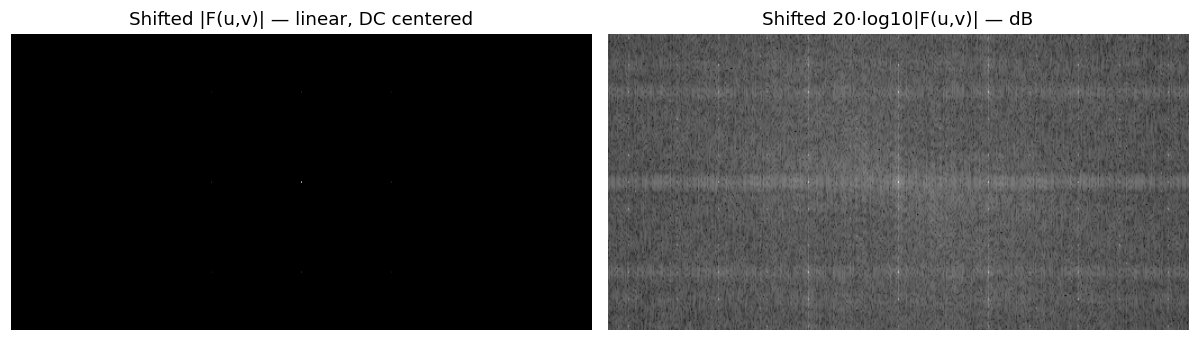

In [5]:
Fshift   = np.fft.fftshift(F)
mag_s    = np.abs(Fshift)
mag_s_db = 20*np.log10(mag_s + 1)

cy, cx = M//2, N//2   # center pixel after shifting = DC location

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].imshow(mag_s,    cmap='gray'); ax[0].set_title("Shifted |F(u,v)| — linear, DC centered"); ax[0].axis('off')
ax[1].imshow(mag_s_db, cmap='gray'); ax[1].set_title("Shifted 20·log10|F(u,v)| — dB");          ax[1].axis('off')
plt.tight_layout(); plt.show()


## 5. Locating the interference components

The corrupted image is dominated by a fine, perfectly regular dot/grid pattern.
A pattern that is periodic with a fixed spatial period in $x$ and/or $y$
produces **sharp, narrow, high-magnitude impulses** in the frequency domain at
the corresponding fundamental frequency and its harmonics — very different
from real image content, whose energy is **smoothly distributed** and decays
gradually from the DC term outward (natural images are dominated by low
frequencies with a roughly $1/f$-like falloff, with no isolated spikes).

This gives a simple, principled way to separate noise from content:

* **Content frequencies**: low-to-mid frequencies, smoothly/broadly spread
  around the DC term, no special structure.
* **Interference frequencies**: isolated, narrow, very high-magnitude points
  sitting *well above* the local noise floor, arranged in a regular lattice
  (because the dot-grid pattern is itself doubly periodic in row and column
  directions, its spectrum is a 2-D "comb" of impulses at integer multiples of
  the fundamental row/column frequencies, including sum/difference
  cross-terms).

We detect these impulses automatically: exclude a small disk around DC
(this protects the genuine low-frequency image content), compute the mean/std
of the remaining ("background") log-magnitude values, and flag any pixel that
sits many standard deviations above that local noise floor as an interference
peak.

In [6]:
# Exclude a small disk around DC so we never touch genuine low-frequency content
yy, xx = np.ogrid[:M, :N]
dist2 = (yy - cy)**2 + (xx - cx)**2
center_radius = 10
exclude = dist2 < center_radius**2

background = mag_s_db[~exclude]
mean_bg, std_bg = background.mean(), background.std()
threshold = mean_bg + 6*std_bg     # "many std above the noise floor"

print(f"Background dB level : mean = {mean_bg:.2f} dB, std = {std_bg:.2f} dB")
print(f"Detection threshold  : {threshold:.2f} dB  (mean + 6*std)")

candidate = (mag_s_db > threshold) & (~exclude)
labels, n_blobs = label(candidate)
print(f"Number of interference peaks detected: {n_blobs}")

peaks = []
for i in range(1, n_blobs + 1):
    ys, xs = np.where(labels == i)
    py, px = int(round(ys.mean())), int(round(xs.mean()))
    peaks.append((py, px, mag_s_db[py, px]))
peaks.sort(key=lambda t: -t[2])

print("\nTop peaks  (row, col, dB)   ->   (Δrow, Δcol) relative to DC:")
for p in peaks[:12]:
    print(f"  {p}   ->   ({p[0]-cy}, {p[1]-cx})")


Background dB level : mean = 61.93 dB, std = 6.76 dB
Detection threshold  : 102.49 dB  (mean + 6*std)
Number of interference peaks detected: 40

Top peaks  (row, col, dB)   ->   (Δrow, Δcol) relative to DC:
  (132, 178, np.float64(133.99045224136844))   ->   (0, -80)
  (132, 338, np.float64(133.99045224136844))   ->   (0, 80)
  (52, 258, np.float64(133.99037885303807))   ->   (-80, 0)
  (212, 258, np.float64(133.99037885303807))   ->   (80, 0)
  (52, 338, np.float64(128.32293045763956))   ->   (-80, 80)
  (212, 178, np.float64(128.32293045763956))   ->   (80, -80)
  (52, 178, np.float64(128.32088804384074))   ->   (-80, -80)
  (212, 338, np.float64(128.32088804384074))   ->   (80, 80)
  (132, 98, np.float64(118.02832364731158))   ->   (0, -160)
  (132, 418, np.float64(118.02832364731158))   ->   (0, 160)
  (28, 258, np.float64(117.9722056847899))   ->   (-104, 0)
  (236, 258, np.float64(117.9722056847899))   ->   (104, 0)


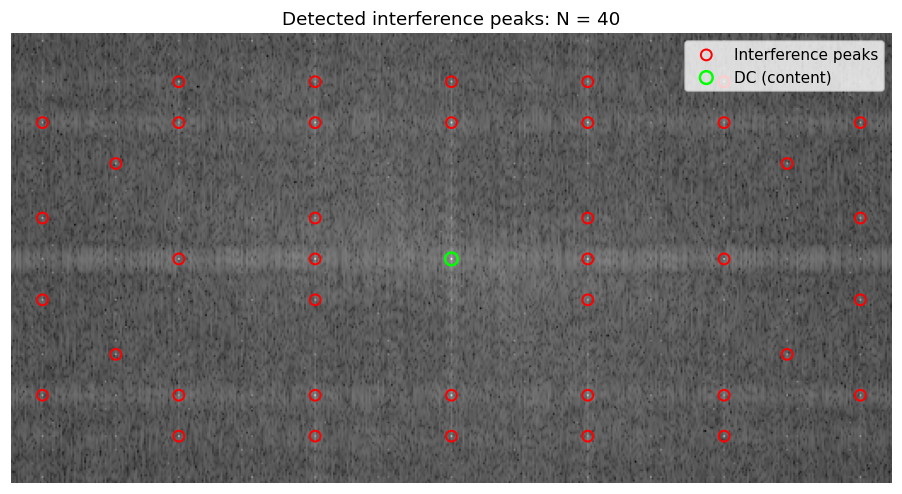

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.imshow(mag_s_db, cmap='gray')
ys = [p[0] for p in peaks]; xs = [p[1] for p in peaks]
ax.scatter(xs, ys, s=50, facecolors='none', edgecolors='red',  linewidths=1.3, label='Interference peaks')
ax.scatter([cx], [cy],     s=70, facecolors='none', edgecolors='lime', linewidths=1.6, label='DC (content)')
ax.set_title(f"Detected interference peaks: N = {len(peaks)}")
ax.legend(loc='upper right')
ax.axis('off')
plt.tight_layout(); plt.show()


**Observation.** The detected peaks form a perfectly regular lattice
symmetric about the DC point (as required for any real-valued image, since
$F(-u,-v) = F^*(u,v)$). The strongest pair sits at $(\Delta u,\Delta v) =
(0,\pm 80)$ and $(\pm 80, 0)$ — i.e. a single dominant horizontal period and a
single dominant vertical period — with weaker peaks at the diagonal
combinations $(\pm80,\pm80)$ and at integer harmonics ($\pm160$, $\pm240$,
…). This is exactly the spectral signature of a separable, doubly-periodic
dot-grid pattern, confirming that these — and only these — narrow, isolated,
abnormally strong components are responsible for the corruption; everything
else in the spectrum belongs to the underlying picture.

## 6. Designing the frequency-domain filter (notch / band-reject)

Since the interference lives at a small, *known* set of isolated frequency
locations while the image content occupies everything else, the natural tool
is a **notch (band-reject) filter**: a filter $H(u,v)$ that is $1$
everywhere, except in a small disk of radius $r$ around each detected
interference peak (and its symmetric partner), where it is set to $0$:

$$
H(u,v) = \begin{cases} 0, & d_k(u,v) \le r \text{ for some detected peak } k \\ 1, & \text{otherwise}\end{cases}
$$

where $d_k(u,v)$ is the Euclidean distance from $(u,v)$ to the $k$-th detected
peak. The radius $r$ is the one free parameter of this design: large enough
to fully cover and suppress each interference spike, but small enough not to
remove legitimate low-frequency image content that happens to sit nearby
(this trade-off is examined quantitatively in Section 9).

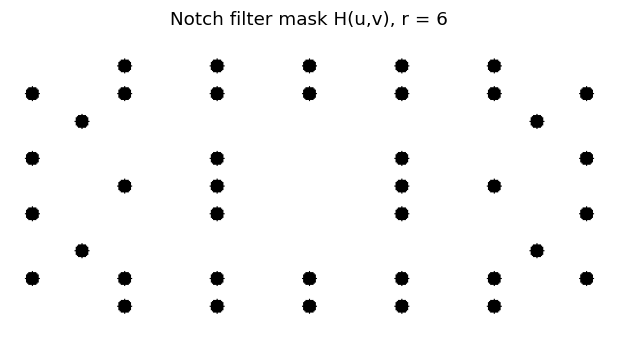

In [8]:
def notch_filter(shape, peak_list, radius):
    Mh, Nh = shape
    yy, xx = np.ogrid[:Mh, :Nh]
    mask = np.ones((Mh, Nh))
    for (py, px) in peak_list:
        d2 = (yy - py)**2 + (xx - px)**2
        mask[d2 <= radius**2] = 0
    return mask

peak_coords = [(p[0], p[1]) for p in peaks]   # (row, col) of every detected interference peak

R = 6   # chosen notch radius (justified by the parameter study in Section 9)
H = notch_filter((M, N), peak_coords, R)

plt.figure(figsize=(7, 3.8))
plt.imshow(H, cmap='gray', vmin=0, vmax=1)
plt.title(f"Notch filter mask H(u,v), r = {R}")
plt.axis('off')
plt.show()


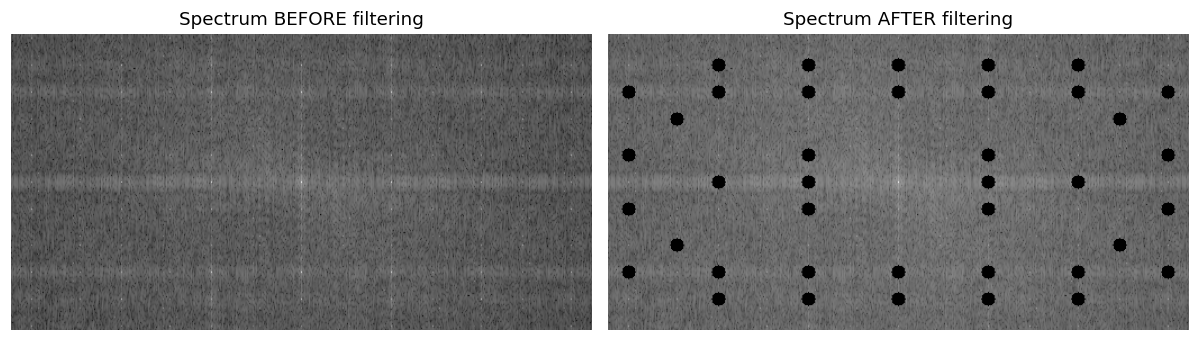

In [9]:
Ffilt = Fshift * H
mag_filt_db = 20*np.log10(np.abs(Ffilt) + 1)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].imshow(mag_s_db,    cmap='gray'); ax[0].set_title("Spectrum BEFORE filtering"); ax[0].axis('off')
ax[1].imshow(mag_filt_db, cmap='gray'); ax[1].set_title("Spectrum AFTER filtering");  ax[1].axis('off')
plt.tight_layout(); plt.show()


## 7. Reconstruction via the inverse DFT

To get back to the spatial domain we undo the shift (`ifftshift`) and apply
the inverse FFT (`ifft2`, the efficient implementation of the IDFT formula in
Section 2). The result is complex-valued due to floating-point round-off; for
a real input image, the imaginary part should be numerically negligible, so
we keep only the real part.

Max |imaginary part| (should be ~0): 8.398597511223283e-14


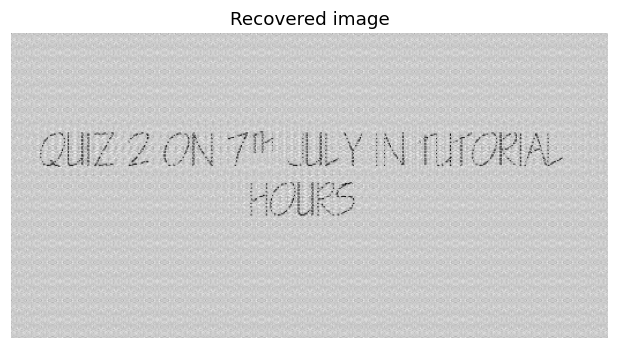

In [10]:
recovered_complex = np.fft.ifft2(np.fft.ifftshift(Ffilt))
print("Max |imaginary part| (should be ~0):", np.max(np.abs(recovered_complex.imag)))

recovered = np.real(recovered_complex)
recovered_disp = recovered - recovered.min()
recovered_disp = (recovered_disp / recovered_disp.max() * 255).astype(np.uint8)

plt.figure(figsize=(7, 3.8))
plt.imshow(recovered_disp, cmap='gray')
plt.title("Recovered image")
plt.axis('off')
plt.show()


**Result.** The hidden message is now legible:

> **"QUIZ 2 ON 7th JULY IN TUTORIAL HOURS"**

The notch filter has successfully suppressed the periodic dot-grid
interference while leaving the underlying text intact.

## 8. Side-by-side comparison

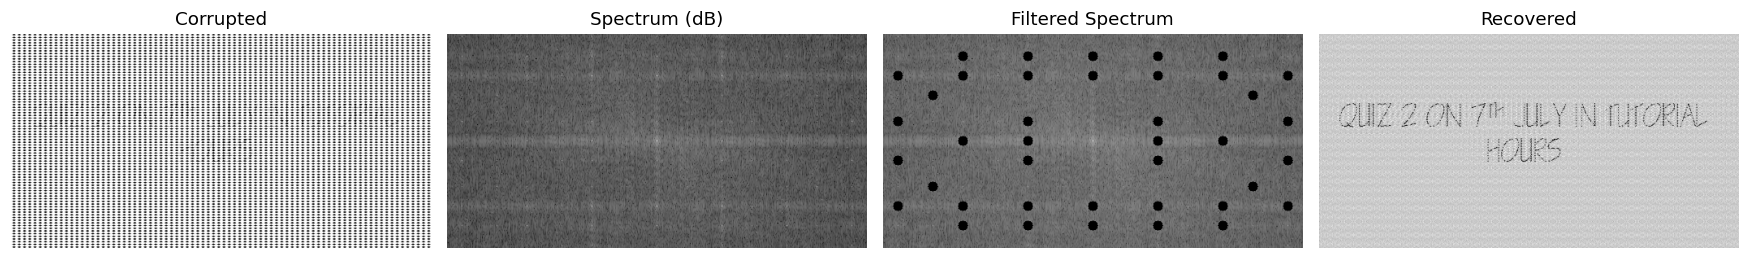

In [11]:
fig, ax = plt.subplots(1, 4, figsize=(16, 4))
ax[0].imshow(I,              cmap='gray'); ax[0].set_title("Corrupted");       ax[0].axis('off')
ax[1].imshow(mag_s_db,       cmap='gray'); ax[1].set_title("Spectrum (dB)");   ax[1].axis('off')
ax[2].imshow(mag_filt_db,    cmap='gray'); ax[2].set_title("Filtered Spectrum"); ax[2].axis('off')
ax[3].imshow(recovered_disp, cmap='gray'); ax[3].set_title("Recovered");       ax[3].axis('off')
plt.tight_layout(); plt.show()


## 9. Parameter study — does removing *more* frequencies always help?

We now vary the notch radius $r$ to see how the choice of filter parameter
affects reconstruction quality.

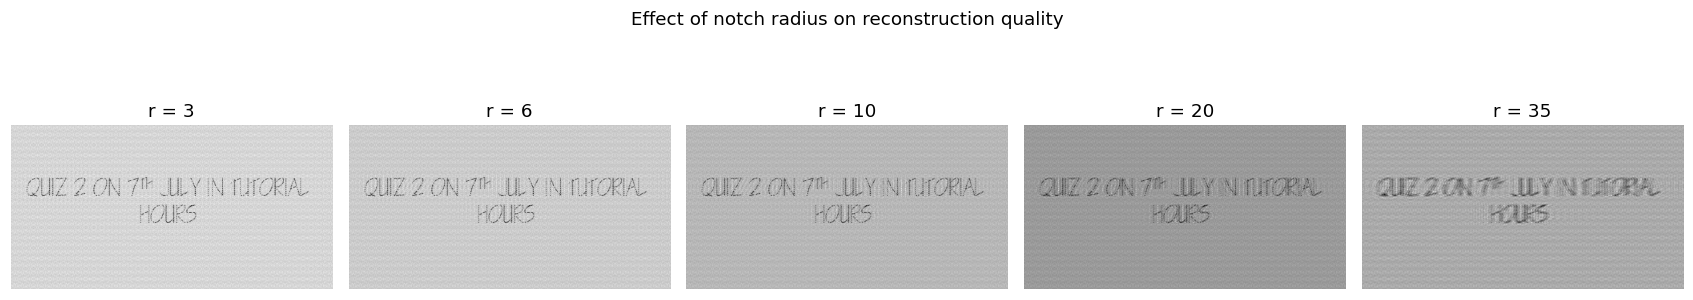

In [12]:
radii = [3, 6, 10, 20, 35]
fig, axes = plt.subplots(1, len(radii), figsize=(3.1*len(radii), 3.4))
for ax, r in zip(axes, radii):
    Hr = notch_filter((M, N), peak_coords, r)
    rec = np.real(np.fft.ifft2(np.fft.ifftshift(Fshift * Hr)))
    d = rec - rec.min(); d = (d/d.max()*255).astype(np.uint8)
    ax.imshow(d, cmap='gray'); ax.set_title(f"r = {r}"); ax.axis('off')
plt.suptitle("Effect of notch radius on reconstruction quality")
plt.tight_layout(); plt.show()


**Observation.** Small radii ($r=3$–$10$) cleanly remove the interference and
leave crisp, fully legible text — the message is already recovered at $r=6$.
As the radius keeps growing ($r=20$, $r=35$), the filter starts eating into
*frequencies that belong to the real image content* (the text strokes have
their own bandwidth, and large notches around peaks at small $\Delta u,\Delta
v$ inevitably overlap the low-frequency content near DC). The result is
visible at $r=35$: the text is harder to read, overall contrast is reduced,
and the image looks increasingly washed out. **So no — removing more
frequencies does not always improve the result.** Once the interference is
gone, any further removal only destroys genuine signal; there is a
"sweet spot" radius that is just large enough to fully cover each spike.

## 10. Discussion and practical applications

**Why frequency-domain restoration works here.** The corruption is *periodic*
and therefore extremely sparse in the frequency domain (a handful of impulses
in an otherwise smooth spectrum), even though in the spatial domain it
overlays *every single pixel* of the image and is visually overwhelming. This
is precisely the situation where frequency-domain filtering vastly
outperforms spatial-domain approaches: a spatial filter (e.g. blurring) would
have to be very aggressive to remove a fine dot grid, destroying detail
everywhere, whereas a frequency-domain notch filter removes only the exact
frequencies responsible for the artifact and leaves everything else
untouched.

**Effect of filter parameters.** As shown above, the notch radius trades off
interference suppression against content preservation: too small and
residual interference remains; too large and genuine image content is
destroyed along with the noise.

**Practical applications of this technique:**

- **Communication systems** — periodic interference from clock harmonics,
  switching power supplies, or carrier leakage can be located and notched out
  of received signals/images without redesigning the whole receiver chain.
- **Remote sensing / satellite imagery** — push-broom and scanning sensors
  often introduce periodic striping or banding (e.g. due to detector
  calibration drift); frequency-domain notch/comb filtering is a standard
  destriping technique.
- **Surveillance and reconnaissance** — as dramatized in this exercise,
  intentional or incidental periodic jamming patterns can be reversed if the
  interference is narrowband in frequency, recovering otherwise unreadable
  imagery.
- **Medical imaging** — MRI and CT images frequently exhibit periodic
  artifacts (RF interference, gantry vibration, ECG-gating ripple); notch
  filtering in k-space (MRI's frequency domain) is routinely used to suppress
  these without blurring anatomical detail.

In all these domains the same principle applies: *identify what is sparse and
structured in frequency, and remove only that*, preserving the broadband
content that carries the actual information.

## 11. Conclusion

- The corrupted image's destruction was caused by a periodic dot-grid
  pattern that is essentially invisible to spatial-domain reasoning but
  produces a small, well-defined lattice of high-magnitude impulses in the
  2-D DFT magnitude spectrum.
- An ideal notch (band-reject) filter, automatically designed from
  statistically-detected spectral peaks, suppresses the interference while
  preserving the underlying picture.
- Applying the inverse DFT to the filtered spectrum reconstructs the image
  and reveals the hidden message: **"QUIZ 2 ON 7th JULY IN TUTORIAL HOURS."**
- Filter parameter choice matters: under-filtering leaves residual
  interference, while over-filtering destroys genuine content — frequency
  domain restoration is a careful trade-off, not a "more is better" process.
